In [8]:
import pandas as pd

lms_df = pd.read_csv("data/lms_loan_daily.csv")

print(lms_df.shape)
print(lms_df.columns)
print(lms_df.head())
print(lms_df[["loan_id", "Customer_ID", "loan_start_date", "overdue_amt"]].head(10))

(137500, 11)
Index(['loan_id', 'Customer_ID', 'loan_start_date', 'tenure',
       'installment_num', 'loan_amt', 'due_amt', 'paid_amt', 'overdue_amt',
       'balance', 'snapshot_date'],
      dtype='object')
                 loan_id Customer_ID loan_start_date  tenure  installment_num  \
0  CUS_0x1000_2023_05_01  CUS_0x1000      2023-05-01      10                0   
1  CUS_0x1000_2023_05_01  CUS_0x1000      2023-05-01      10                1   
2  CUS_0x1000_2023_05_01  CUS_0x1000      2023-05-01      10                2   
3  CUS_0x1000_2023_05_01  CUS_0x1000      2023-05-01      10                3   
4  CUS_0x1000_2023_05_01  CUS_0x1000      2023-05-01      10                4   

   loan_amt  due_amt  paid_amt  overdue_amt  balance snapshot_date  
0     10000      0.0       0.0          0.0  10000.0    2023-05-01  
1     10000   1000.0    1000.0          0.0   9000.0    2023-06-01  
2     10000   1000.0    1000.0          0.0   8000.0    2023-07-01  
3     10000   1000.0       0

In [9]:
print(lms_df["Customer_ID"].head(20))

print("Null Customer_ID:")
print(lms_df["Customer_ID"].isna().sum())

print("Unique customers:")
print(lms_df["Customer_ID"].nunique())

0     CUS_0x1000
1     CUS_0x1000
2     CUS_0x1000
3     CUS_0x1000
4     CUS_0x1000
5     CUS_0x1000
6     CUS_0x1000
7     CUS_0x1000
8     CUS_0x1000
9     CUS_0x1000
10    CUS_0x1000
11    CUS_0x1009
12    CUS_0x1009
13    CUS_0x1009
14    CUS_0x1009
15    CUS_0x1009
16    CUS_0x1009
17    CUS_0x1009
18    CUS_0x1009
19    CUS_0x1009
Name: Customer_ID, dtype: object
Null Customer_ID:
0
Unique customers:
12500


In [10]:
lms_df["loan_start_date"] = pd.to_datetime(
    lms_df["loan_start_date"]
)

print(
    lms_df["loan_start_date"].min()
)

print(
    lms_df["loan_start_date"].max()
)

2023-01-01 00:00:00
2025-01-01 00:00:00


In [11]:
lms_monitor = lms_df[
    (lms_df["loan_start_date"] >= "2024-07-01")
    &
    (lms_df["loan_start_date"] <= "2024-12-01")
].copy()

print(lms_monitor.shape)

lms_monitor.head()

(33000, 11)


,loan_id,Customer_ID,loan_start_date,tenure,installment_num,loan_amt,due_amt,paid_amt,overdue_amt,balance,snapshot_date
132,CUS_0x1038_2024_10_01,CUS_0x1038,2024-10-01,10,0,10000,0.0,0.0,0.0,10000.0,2024-10-01
133,CUS_0x1038_2024_10_01,CUS_0x1038,2024-10-01,10,1,10000,1000.0,1000.0,0.0,9000.0,2024-11-01
134,CUS_0x1038_2024_10_01,CUS_0x1038,2024-10-01,10,2,10000,1000.0,1000.0,0.0,8000.0,2024-12-01
135,CUS_0x1038_2024_10_01,CUS_0x1038,2024-10-01,10,3,10000,1000.0,1000.0,0.0,7000.0,2025-01-01
136,CUS_0x1038_2024_10_01,CUS_0x1038,2024-10-01,10,4,10000,1000.0,1000.0,0.0,6000.0,2025-02-01


In [12]:
lms_monitor["actual_label"] = (
    lms_monitor["overdue_amt"] > 0
).astype(int)

print(
    lms_monitor["actual_label"]
    .value_counts()
)

actual_label
0    26015
1     6985
Name: count, dtype: int64


In [13]:
lms_monitor["snapshot_date"] = (
    lms_monitor["loan_start_date"]
)

monitor_label_store = (
    lms_monitor
    .groupby(
        ["Customer_ID", "snapshot_date"],
        as_index=False
    )
    .agg(
        actual_label=("actual_label", "max")
    )
)

print(monitor_label_store.shape)

monitor_label_store.head()

(3000, 3)


,Customer_ID,snapshot_date,actual_label
0,CUS_0x1038,2024-10-01,0
1,CUS_0x103e,2024-12-01,0
2,CUS_0x104f,2024-10-01,0
3,CUS_0x107e,2024-11-01,0
4,CUS_0x1087,2024-09-01,0


In [16]:
prediction_df = pd.read_parquet(
    "datamart/gold/model_predictions/champion_model_predictions.parquet"
)

prediction_df.head()

,Customer_ID,snapshot_date,model_name,model_version,pred_proba,pred_label
0,cus_0x1108,2024-07-01,xgboost,credit_model_xgboost_2026_06_17,0.216618,0
1,cus_0x13b5,2024-07-01,xgboost,credit_model_xgboost_2026_06_17,0.360143,0
2,cus_0x13b8,2024-07-01,xgboost,credit_model_xgboost_2026_06_17,0.125339,0
3,cus_0x144f,2024-07-01,xgboost,credit_model_xgboost_2026_06_17,0.788867,1
4,cus_0x14ec,2024-07-01,xgboost,credit_model_xgboost_2026_06_17,0.514122,1


In [17]:
prediction_df["Customer_ID"] = (
    prediction_df["Customer_ID"]
    .astype(str)
    .str.strip()
    .str.lower()
)

monitor_label_store["Customer_ID"] = (
    monitor_label_store["Customer_ID"]
    .astype(str)
    .str.strip()
    .str.lower()
)

In [18]:
prediction_df["snapshot_date"] = pd.to_datetime(
    prediction_df["snapshot_date"]
)

monitor_label_store["snapshot_date"] = pd.to_datetime(
    monitor_label_store["snapshot_date"]
)

In [19]:
pred_keys = set(
    zip(
        prediction_df["Customer_ID"],
        prediction_df["snapshot_date"]
    )
)

actual_keys = set(
    zip(
        monitor_label_store["Customer_ID"],
        monitor_label_store["snapshot_date"]
    )
)

print("Matching keys:", len(pred_keys & actual_keys))

Matching keys: 3000


In [20]:
monitor_df = prediction_df.merge(
    monitor_label_store,
    on=["Customer_ID", "snapshot_date"],
    how="inner"
)

print(monitor_df.shape)
print(monitor_df["actual_label"].value_counts())
monitor_df.head()

(3000, 7)
actual_label
0    2130
1     870
Name: count, dtype: int64


,Customer_ID,snapshot_date,model_name,model_version,pred_proba,pred_label,actual_label
0,cus_0x1108,2024-07-01,xgboost,credit_model_xgboost_2026_06_17,0.216618,0,1
1,cus_0x13b5,2024-07-01,xgboost,credit_model_xgboost_2026_06_17,0.360143,0,0
2,cus_0x13b8,2024-07-01,xgboost,credit_model_xgboost_2026_06_17,0.125339,0,0
3,cus_0x144f,2024-07-01,xgboost,credit_model_xgboost_2026_06_17,0.788867,1,1
4,cus_0x14ec,2024-07-01,xgboost,credit_model_xgboost_2026_06_17,0.514122,1,1


In [21]:
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

monitoring_results = []

for month in sorted(monitor_df["snapshot_date"].unique()):
    temp = monitor_df[monitor_df["snapshot_date"] == month]

    monitoring_results.append({
        "snapshot_date": month,
        "n_records": len(temp),
        "actual_default_rate": temp["actual_label"].mean(),
        "predicted_default_rate": temp["pred_label"].mean(),
        "avg_pred_proba": temp["pred_proba"].mean(),
        "roc_auc": roc_auc_score(temp["actual_label"], temp["pred_proba"]),
        "accuracy": accuracy_score(temp["actual_label"], temp["pred_label"]),
        "precision": precision_score(temp["actual_label"], temp["pred_label"], zero_division=0),
        "recall": recall_score(temp["actual_label"], temp["pred_label"], zero_division=0),
        "f1": f1_score(temp["actual_label"], temp["pred_label"], zero_division=0),
    })

monitoring_df = pd.DataFrame(monitoring_results)
monitoring_df

,snapshot_date,n_records,actual_default_rate,predicted_default_rate,avg_pred_proba,roc_auc,accuracy,precision,recall,f1
0,2024-07-01,505,0.306931,0.299010,0.396046,0.772682,0.750495,0.596026,0.580645,0.588235
1,2024-08-01,543,0.300184,0.281768,0.384325,0.723232,0.734807,0.562092,0.527607,0.544304
2,2024-09-01,493,0.330629,0.283976,0.379627,0.765012,0.750507,0.642857,0.552147,0.594059
3,2024-10-01,456,0.245614,0.239035,0.374691,0.753763,0.778509,0.550459,0.535714,0.542986
4,2024-11-01,488,0.280738,0.288934,0.388690,0.761204,0.774590,0.595745,0.613139,0.604317
5,2024-12-01,515,0.271845,0.254369,0.368231,0.805124,0.792233,0.625954,0.585714,0.605166


In [22]:
import os

os.makedirs("datamart/gold/model_monitoring/champion_model", exist_ok=True)

monitoring_df.to_parquet(
    "datamart/gold/model_monitoring/champion_model/monitoring_metrics.parquet",
    index=False
)

In [24]:
import matplotlib.pyplot as plt

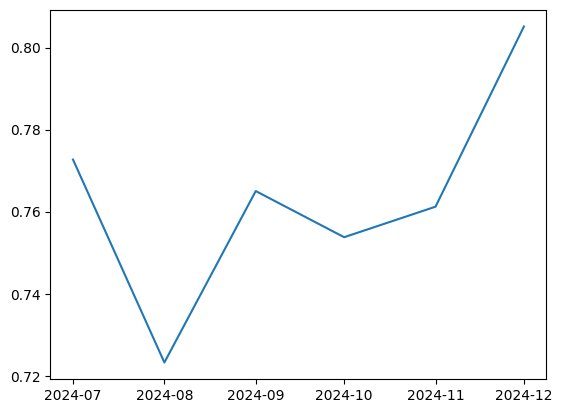

In [25]:
plt.plot(monitoring_df["snapshot_date"],
         monitoring_df["roc_auc"])

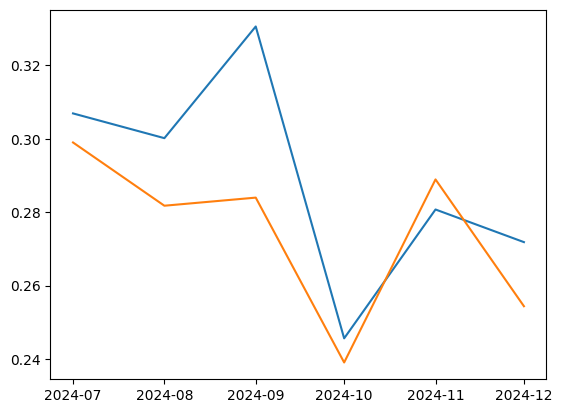

In [26]:
plt.plot(monitoring_df["snapshot_date"],
         monitoring_df["actual_default_rate"])

plt.plot(monitoring_df["snapshot_date"],
         monitoring_df["predicted_default_rate"])